# MNIST MLP3 — Muon horizon-optimized baseline

Runs a separate 30-epoch Muon + auxiliary AdamW candidate in `sgd_momentum_muon_horizon_optimized`. The recipe lowers the matrix peak LR and LR floor, strengthens matrix decay, and keeps Muon on `fc1.weight` and `fc2.weight` only. The official test set remains monitoring-only.

In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    BaselineConfig,
    DEFAULT_BASELINE_SEEDS,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
    plot_all_replicates,
    run_baseline_replicates,
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

BASE_RUN_ROOT = Path(os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
DATA_DIR = Path(os.environ.get('RG_BASELINE_DATA_DIR', ROOT / 'data')).expanduser().resolve()
for directory in (BASE_RUN_ROOT, RUN_ROOT, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('versioned suite root:', RUN_ROOT)


versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3


In [2]:
CONFIG = BaselineConfig(
    optimizer='sgd_momentum_muon',
    epochs=30,
    validation_size=5_000,
    muon_parameter_names=('fc1.weight', 'fc2.weight'),
    muon_learning_rate=0.01,
    muon_min_learning_rate=2e-4,
    muon_warmup_epochs=2,
    muon_momentum=0.95,
    muon_nesterov=True,
    muon_weight_decay=0.02,
    muon_newton_schulz_steps=5,
    muon_aux_learning_rate=3e-4,
    muon_aux_min_learning_rate=3e-6,
    muon_aux_beta1=0.90,
    muon_aux_beta2=0.95,
    muon_aux_weight_decay=0.01,
    ww_randomize=True,
    save_epoch_checkpoints=True,
)
CONFIG.validate()
if CONFIG.recipe_version != MNIST_REFERENCE_RECIPE_VERSION:
    raise RuntimeError('Notebook expects current MNIST recipe version.')
assert CONFIG.muon_parameter_names == ('fc1.weight', 'fc2.weight')
SEEDS = DEFAULT_BASELINE_SEEDS
assert len(SEEDS) == 3 and len(set(SEEDS)) == 3
RUN_DIR = RUN_ROOT / 'sgd_momentum_muon_horizon_optimized'
PLOT_DIR = RUN_DIR / 'plots'
for directory in (RUN_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('optimizer implementation:', CONFIG.optimizer_label)
print('horizon-optimized run directory:', RUN_DIR)
display(pd.DataFrame([CONFIG.__dict__]))


optimizer implementation: Muon + auxiliary AdamW
horizon-optimized run directory: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/sgd_momentum_muon_horizon_optimized


,optimizer,recipe_version,initialization,seed,epochs,batch_size,validation_size,split_seed,num_workers,grad_clip_norm,train_eval_max_batches,schedule,checkpoint_every_epochs,test_monitoring_only,sgd_learning_rate,sgd_min_learning_rate,sgd_warmup_epochs,sgd_momentum,sgd_dampening,sgd_nesterov,sgd_weight_decay,adamw_learning_rate,adamw_min_learning_rate,adamw_warmup_epochs,adamw_beta1,adamw_beta2,adamw_eps,adamw_weight_decay,adamw_amsgrad,muon_parameter_names,muon_learning_rate,muon_min_learning_rate,muon_warmup_epochs,muon_momentum,muon_nesterov,muon_weight_decay,muon_newton_schulz_steps,muon_eps,muon_aux_learning_rate,muon_aux_min_learning_rate,muon_aux_beta1,muon_aux_beta2,muon_aux_eps,muon_aux_weight_decay,ww_min_evals,ww_max_evals,ww_svd_method,ww_randomize,save_epoch_checkpoints,strict_metrics
0,sgd_momentum_muon,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.001,0.00001,1,0.9,0.999,1.000000e-08,0.01,False,"(fc1.weight, fc2.weight)",0.01,0.0002,2,0.95,True,0.02,5,1.000000e-07,0.0003,0.000003,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True



=== Muon + auxiliary AdamW: replicate 1/3, seed=1337 ===


PyTorch is available but CUDA is not. Defaulting to NumPy for SVD


Import error , reetting to svd accurate methods


Running on macOS.
Running on macOS.


SMALL N PL FIT


...

epoch=028 | Muon + auxiliary AdamW | lr=3.229e-04 | train=1.0000 | val=0.9890 | test=0.9868


SMALL N PL FIT


epoch=029 | Muon + auxiliary AdamW | lr=2.308e-04 | train=1.0000 | val=0.9890 | test=0.9868


SMALL N PL FIT


epoch=030 | Muon + auxiliary AdamW | lr=2.000e-04 | train=1.0000 | val=0.9890 | test=0.9869


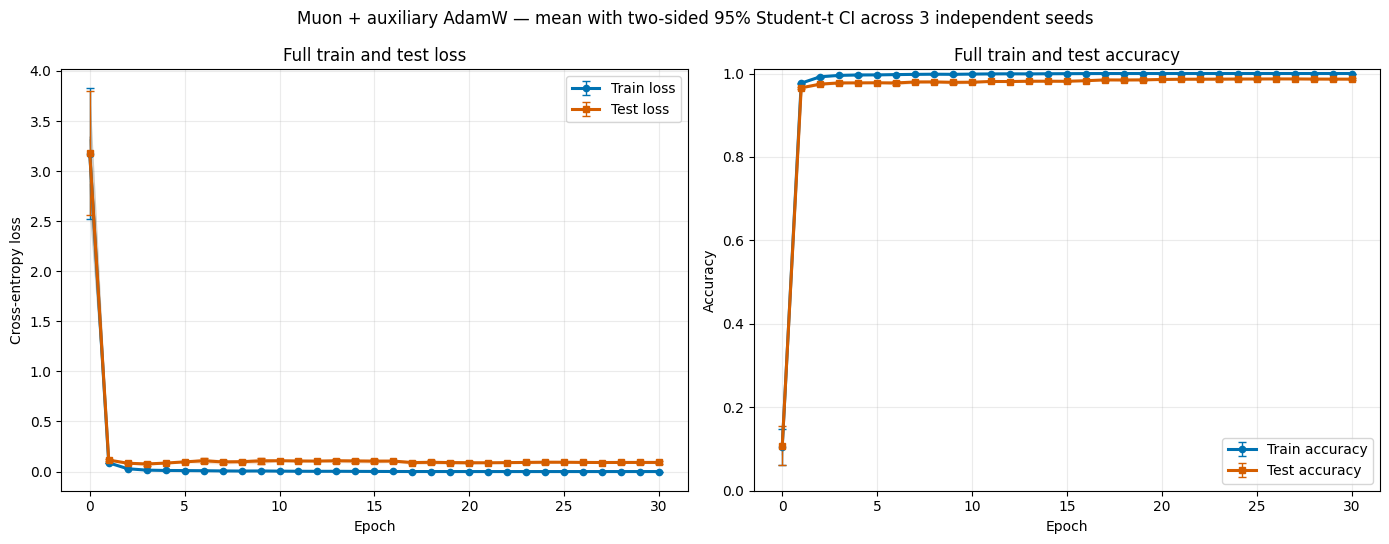

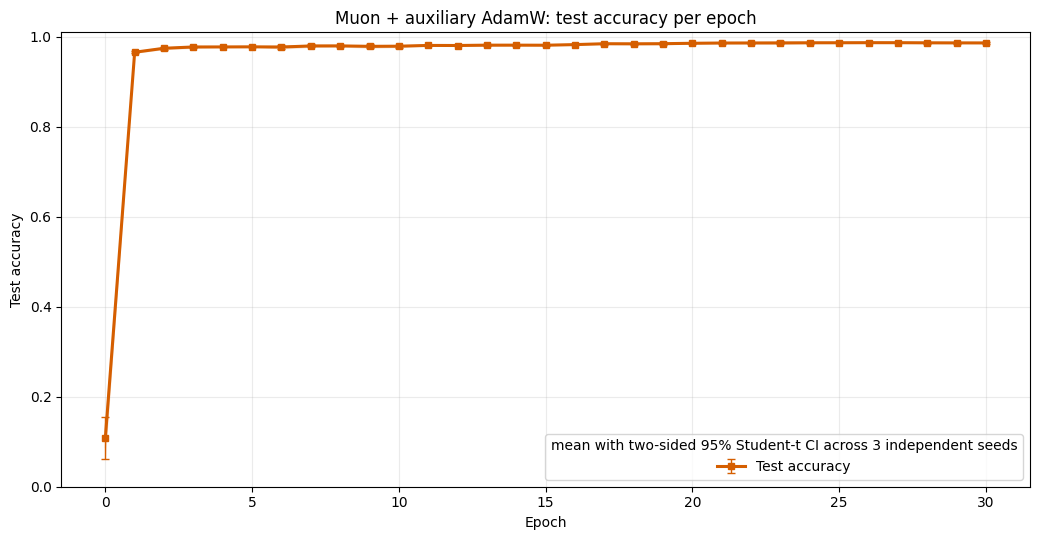

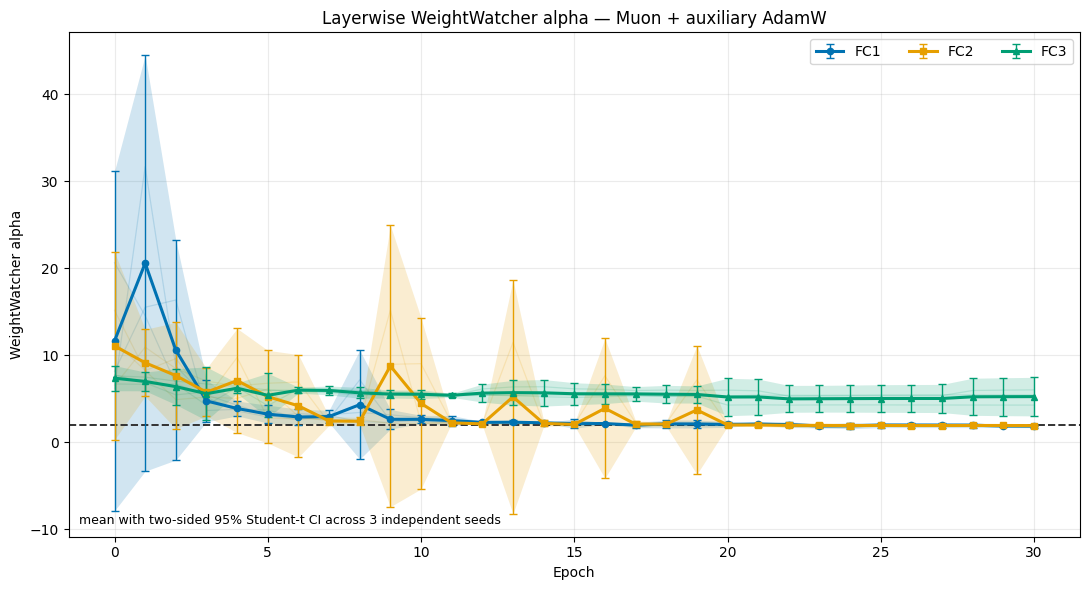

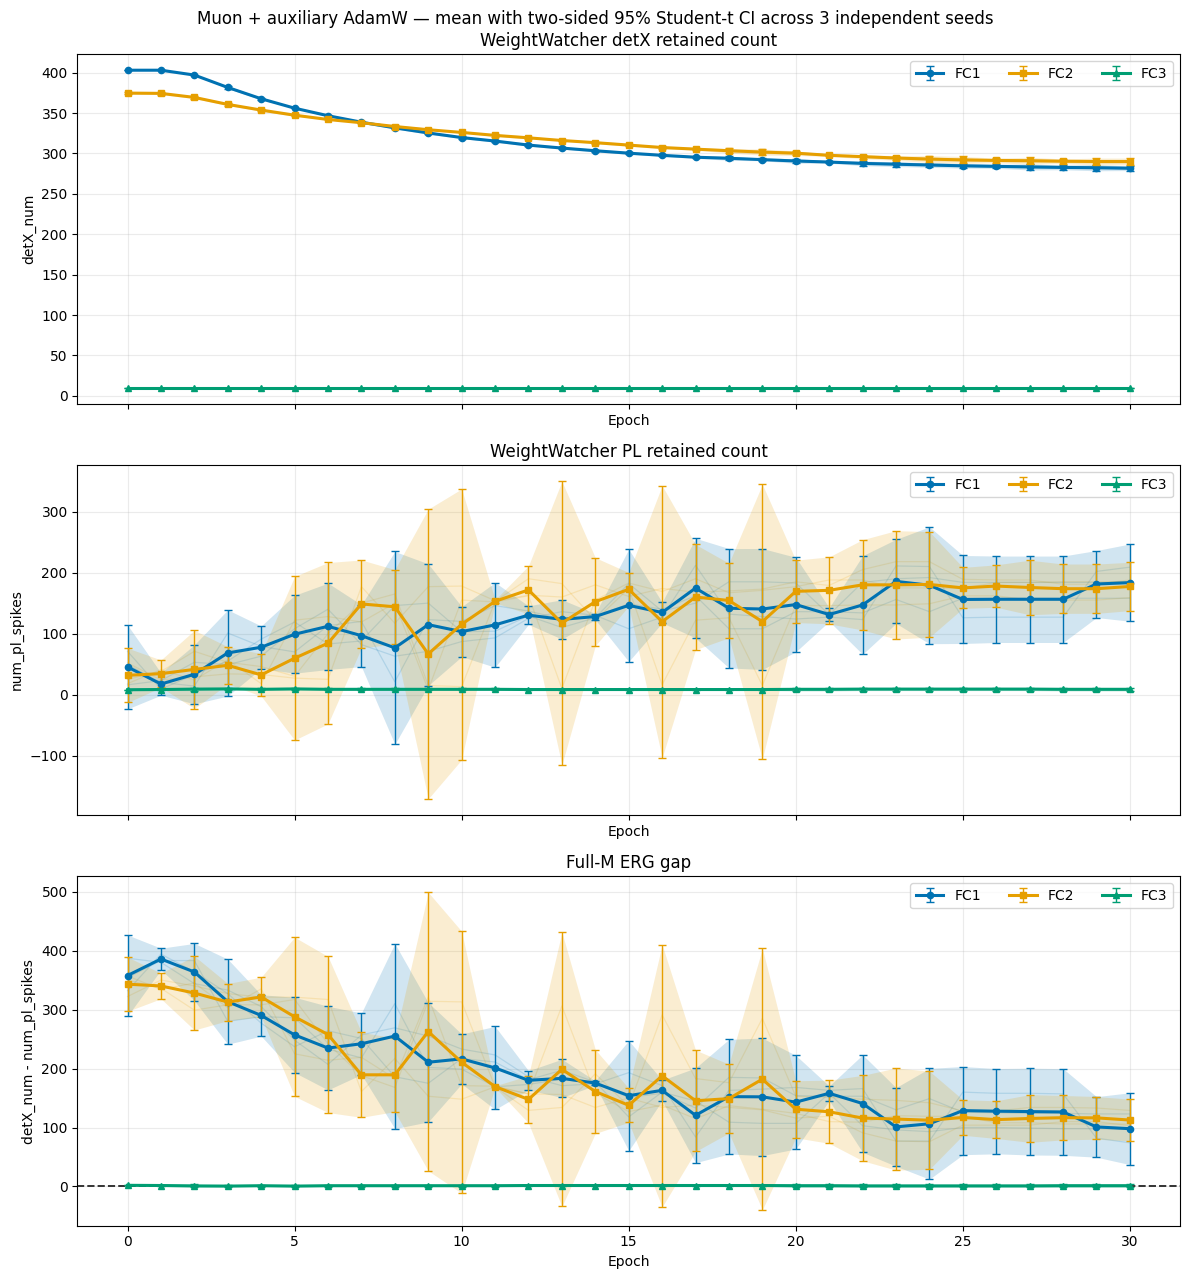

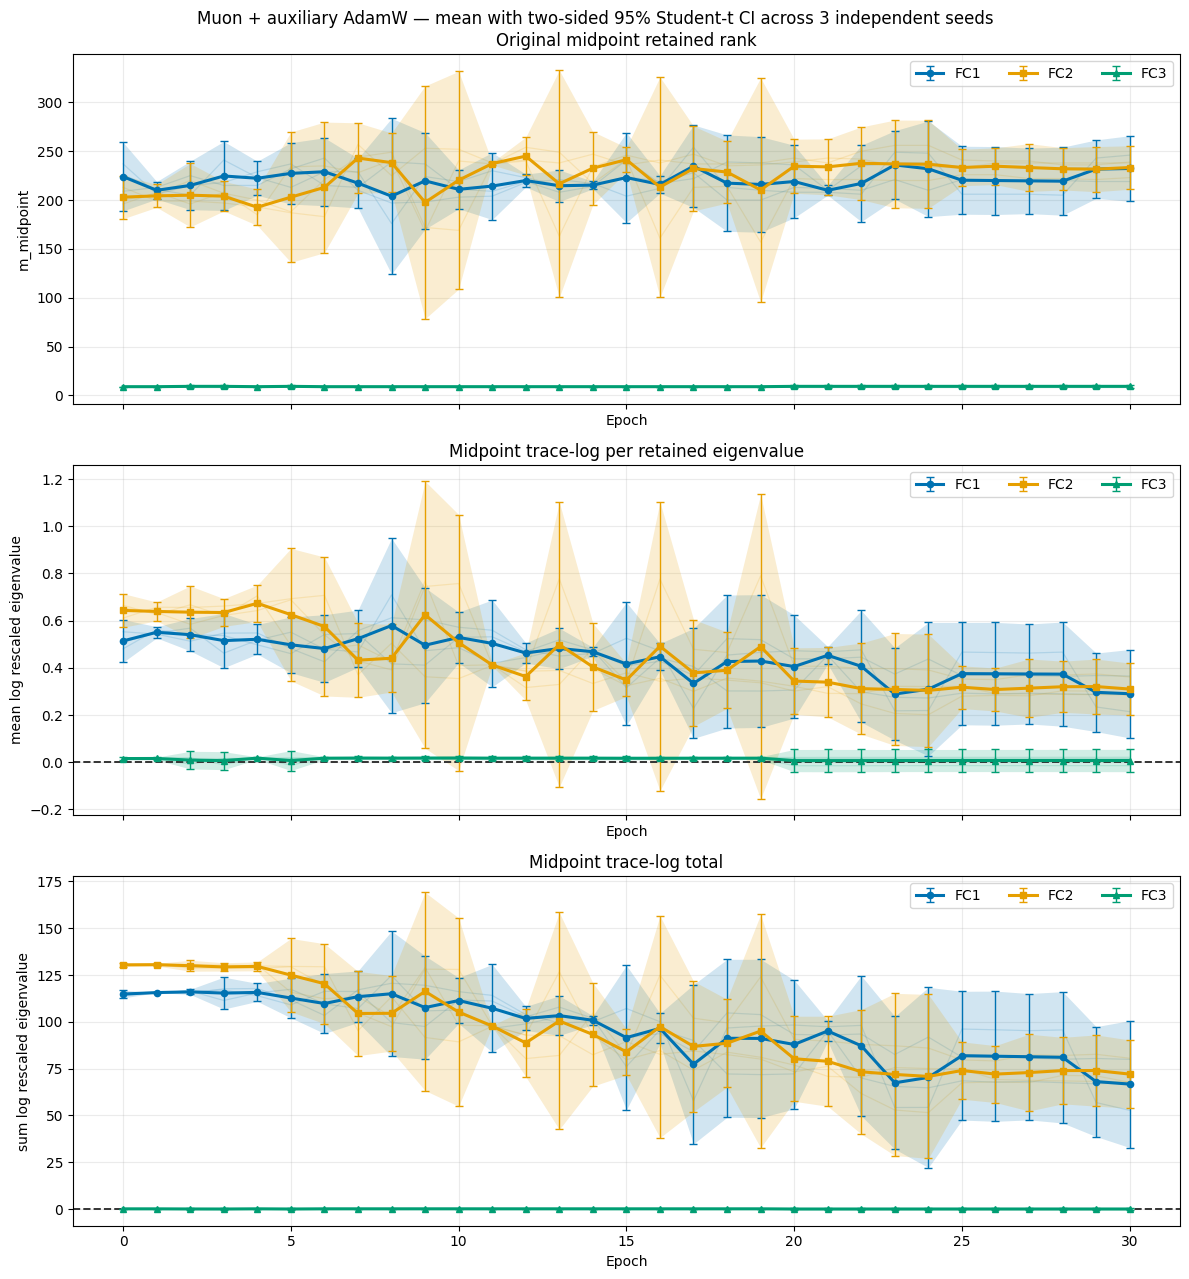

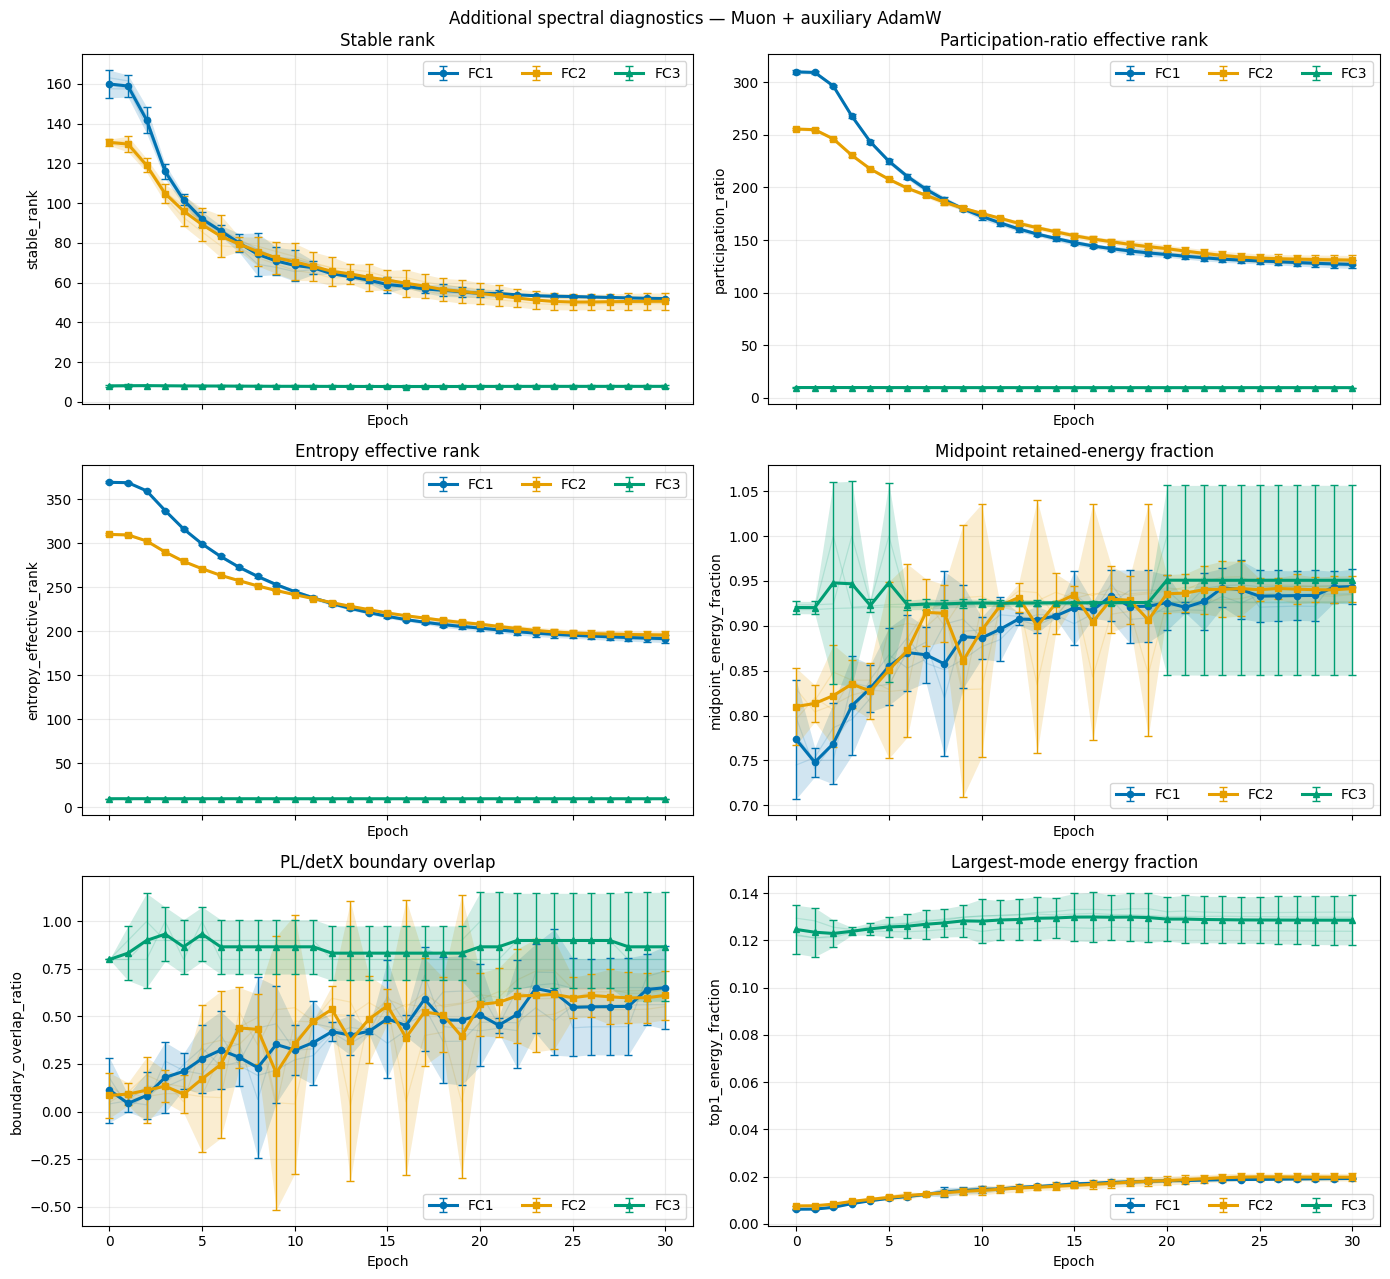

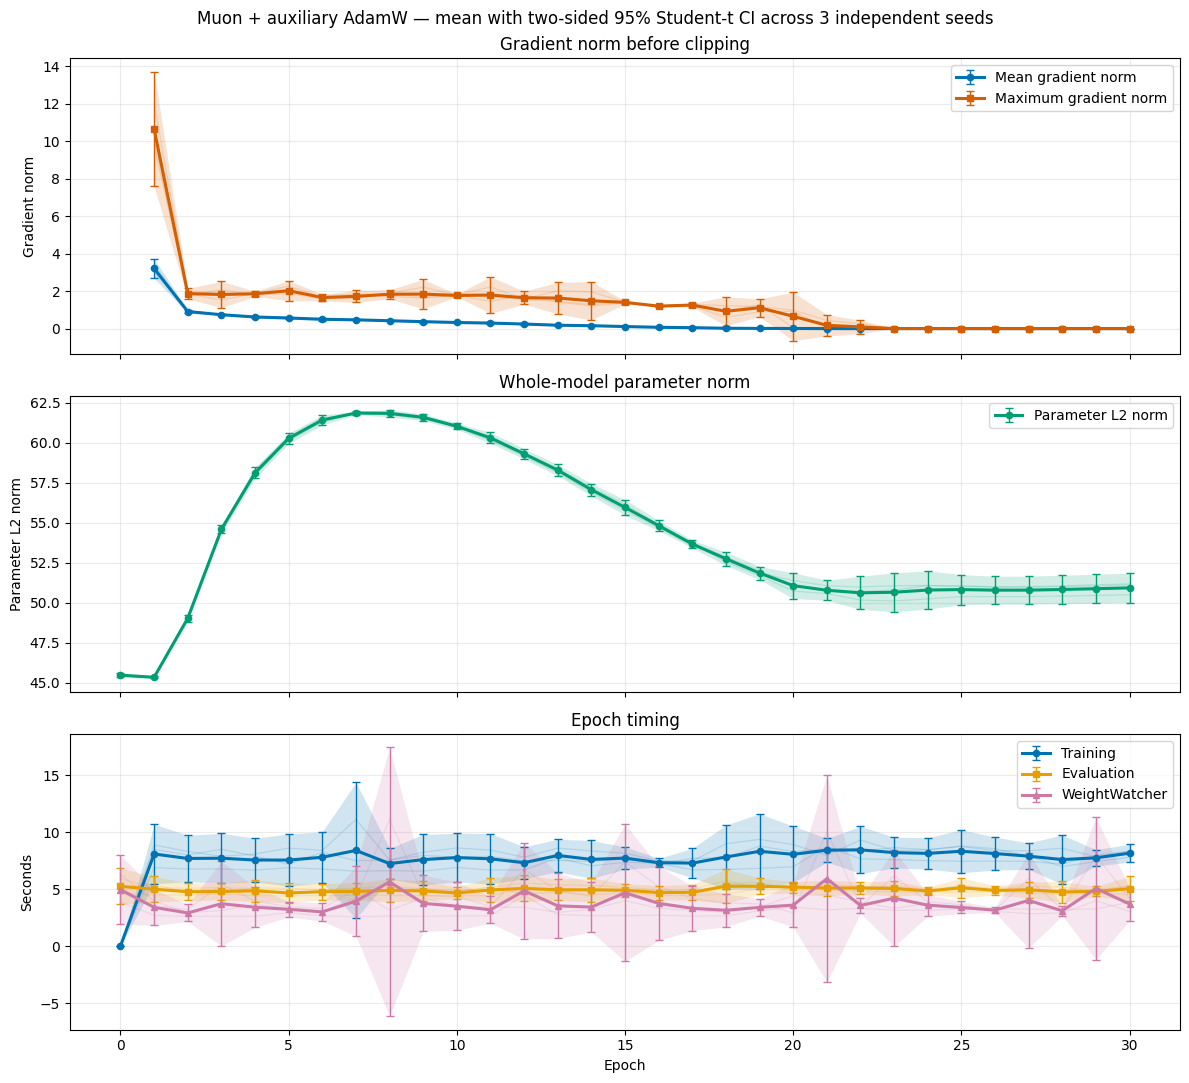

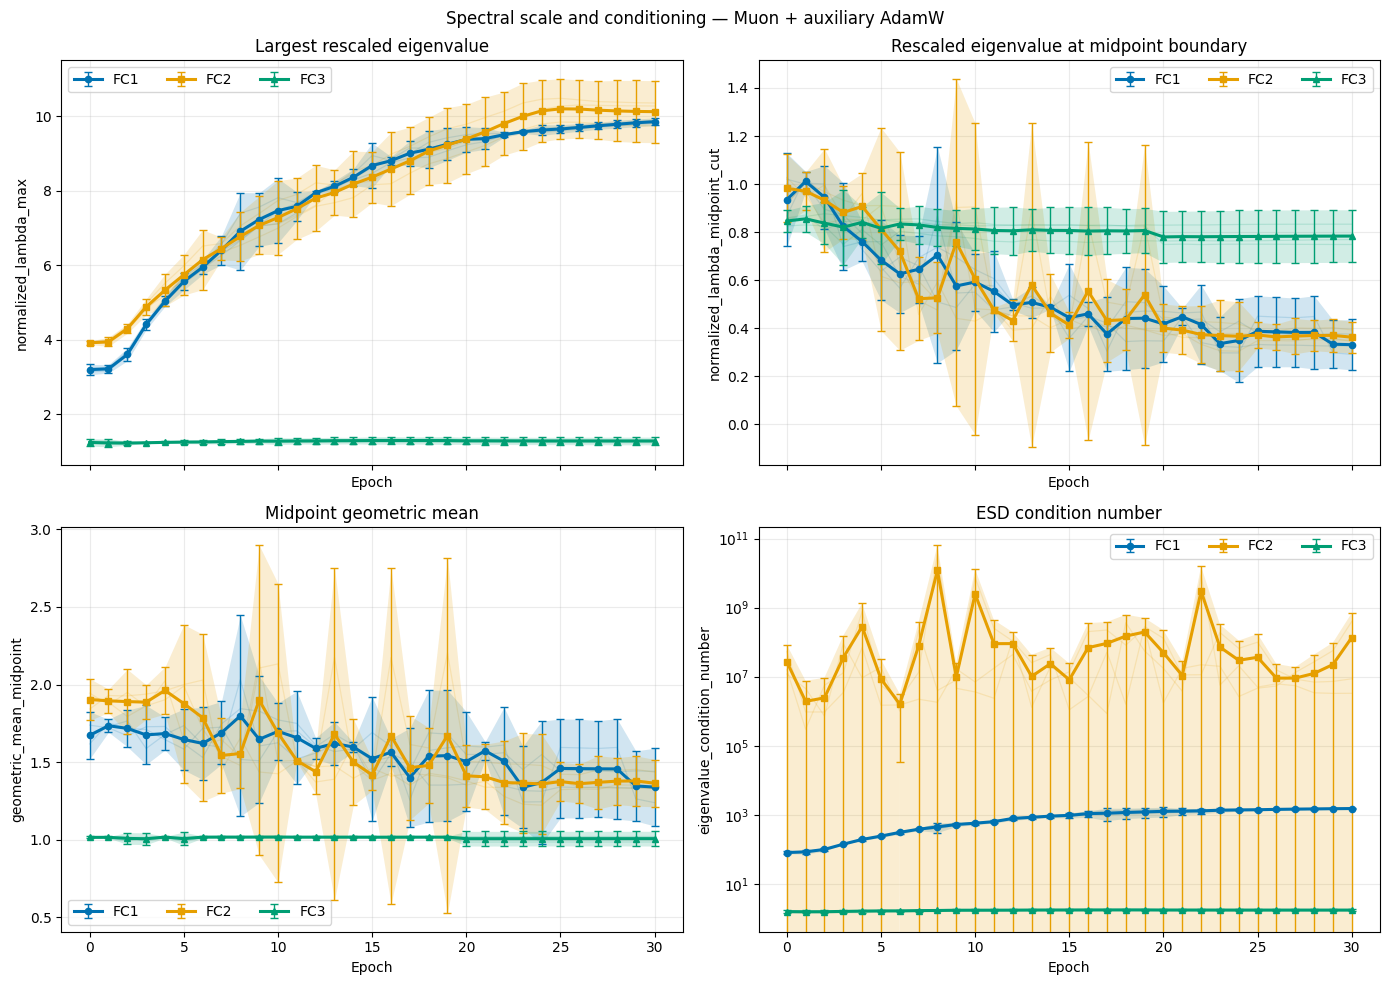

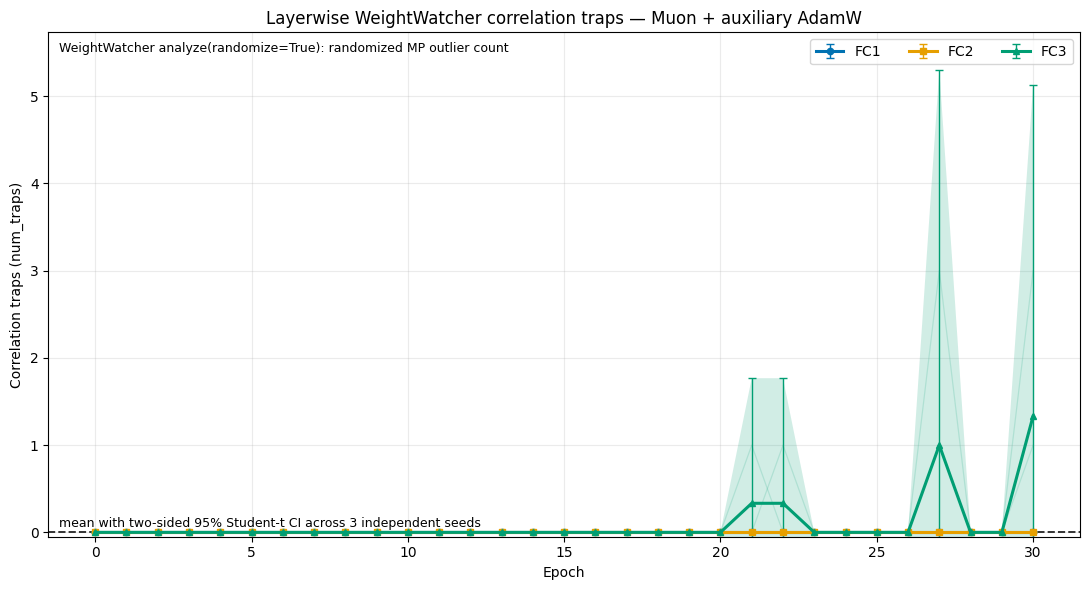

[<Figure size 1400x550 with 2 Axes>,
 <Figure size 1050x550 with 1 Axes>,
 <Figure size 1100x600 with 1 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1400x1300 with 6 Axes>,
 <Figure size 1200x1100 with 3 Axes>,
 <Figure size 1400x1000 with 4 Axes>,
 <Figure size 1100x600 with 1 Axes>]

In [3]:
suite = run_baseline_replicates(
    CONFIG,
    seeds=SEEDS,
    data_dir=DATA_DIR,
    output_dir=RUN_DIR,
    progress=True,
    confidence=0.95,
    resume=True,
    overwrite=False,
)
assert suite.config_template.recipe_version == MNIST_REFERENCE_RECIPE_VERSION
plot_all_replicates(suite, output_dir=PLOT_DIR, show=True)


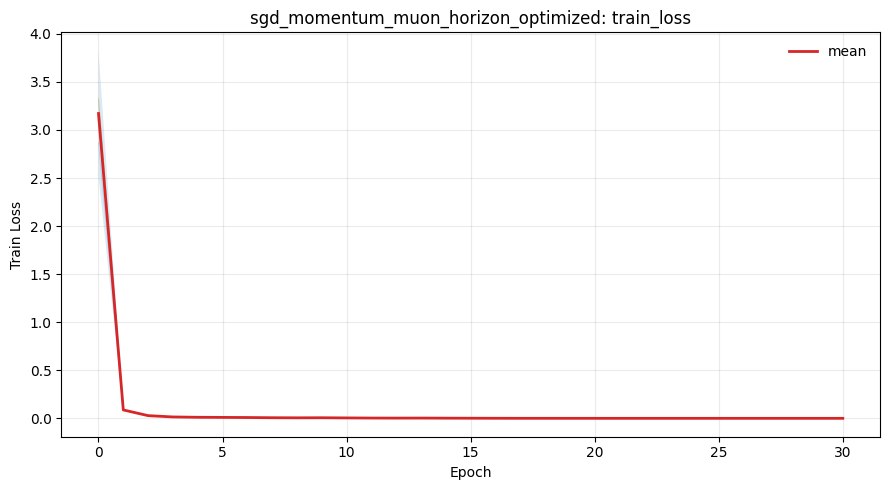

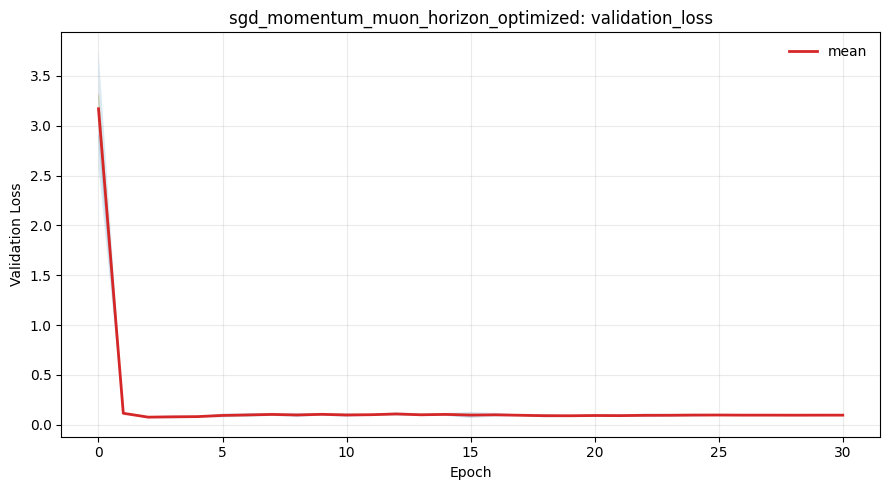

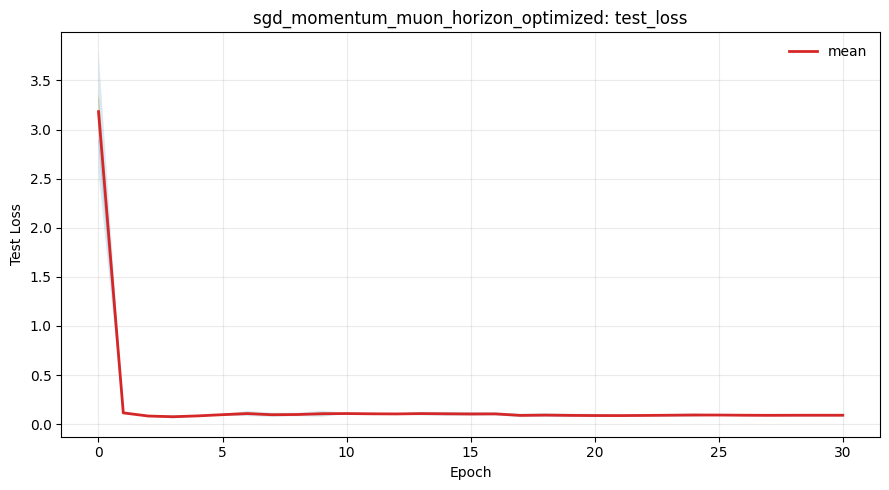

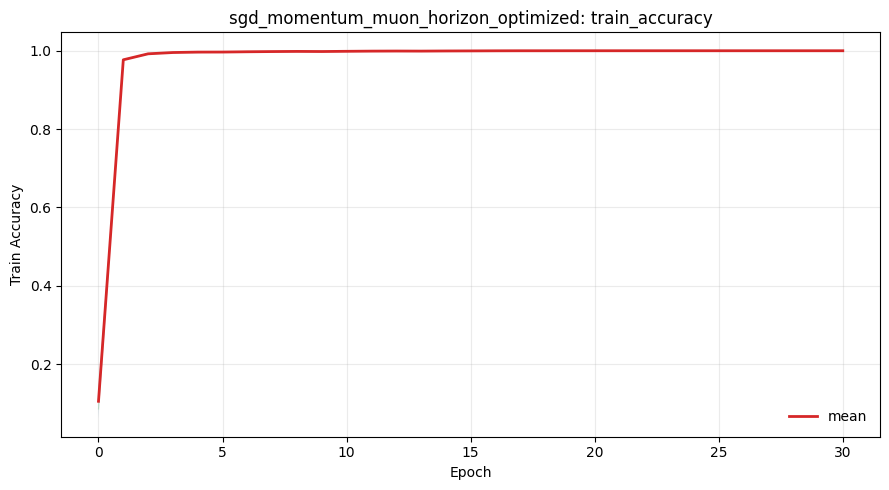

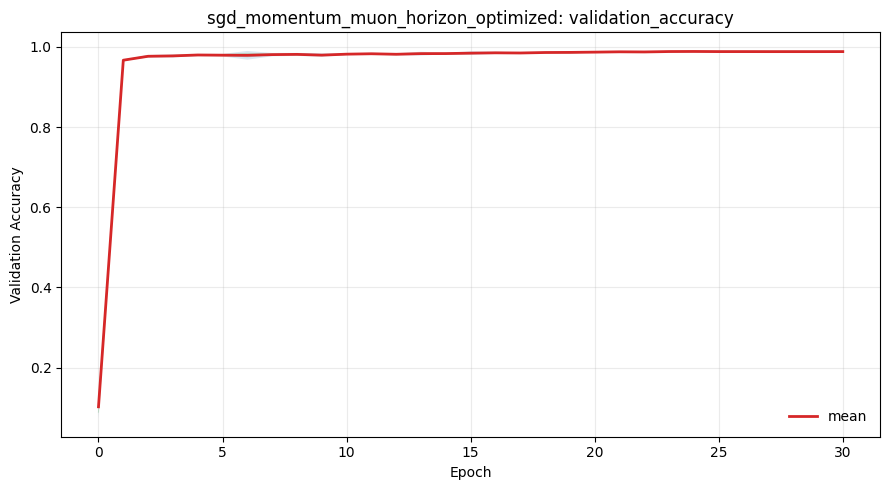

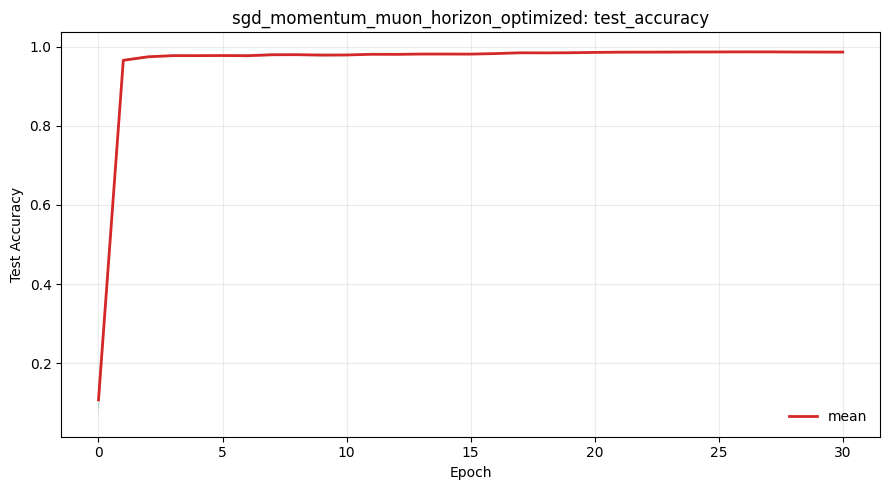

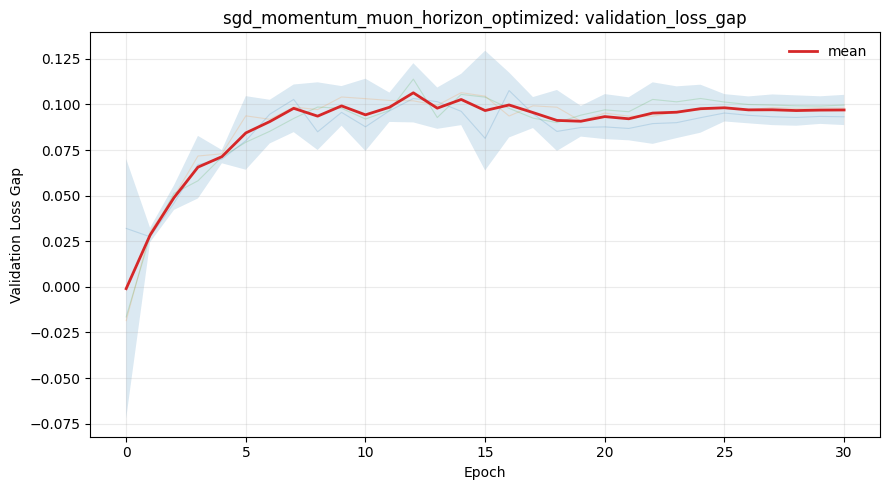

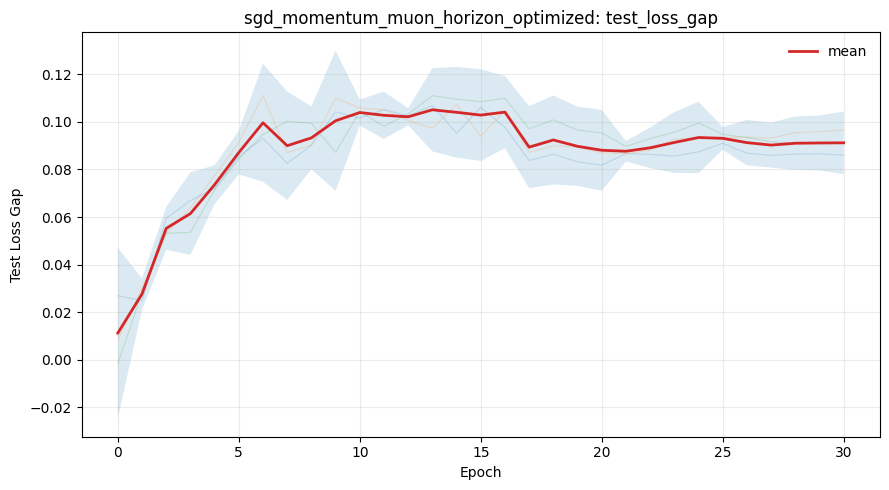

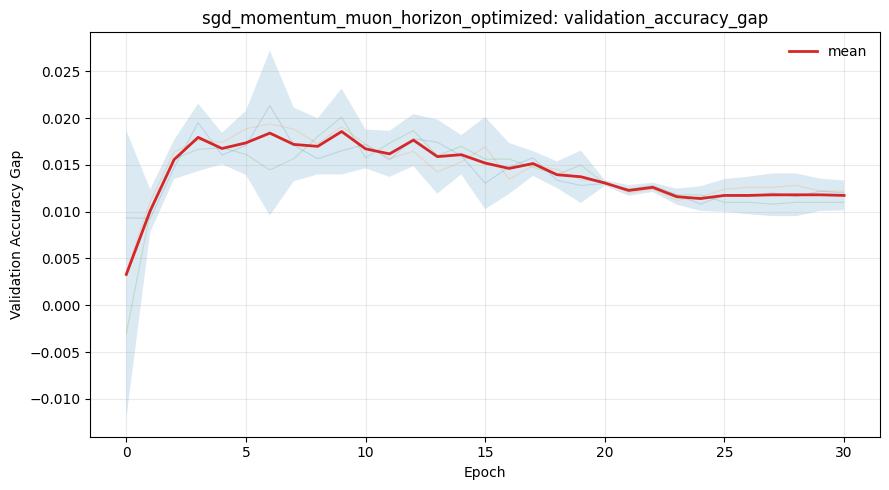

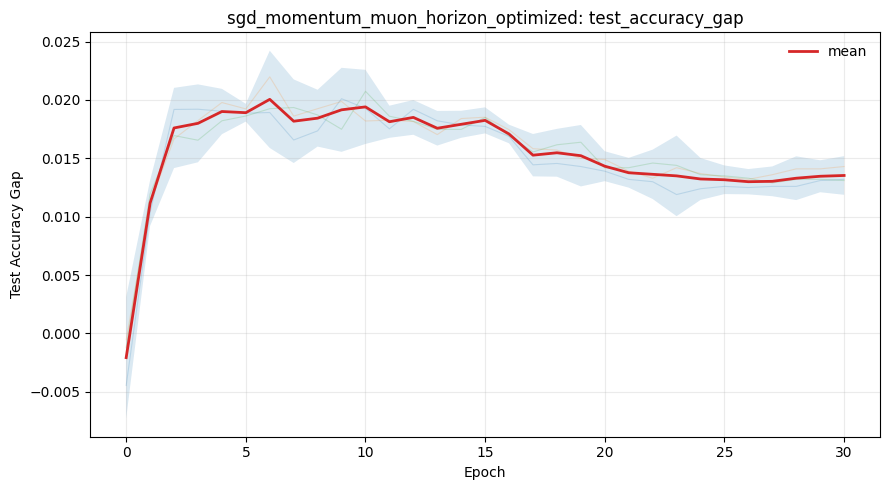

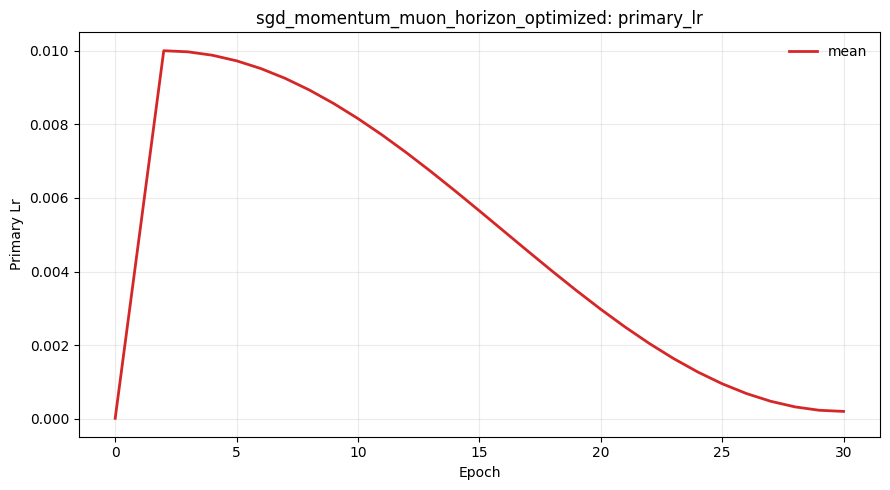

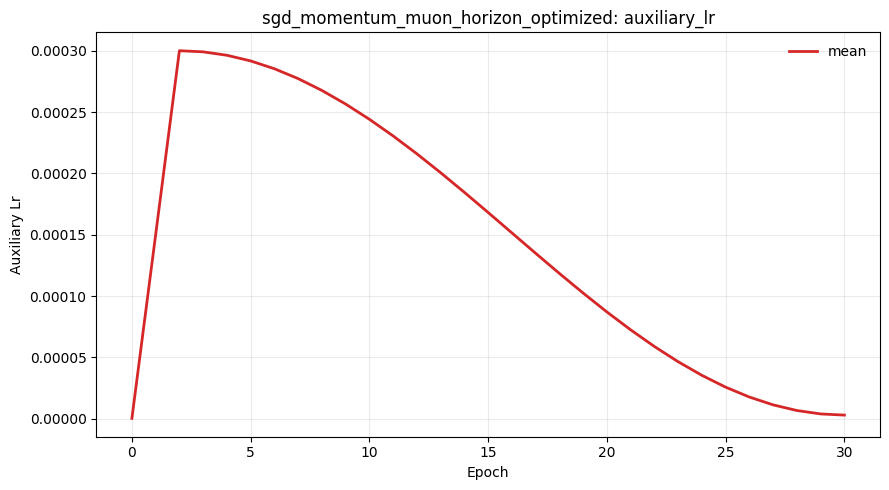

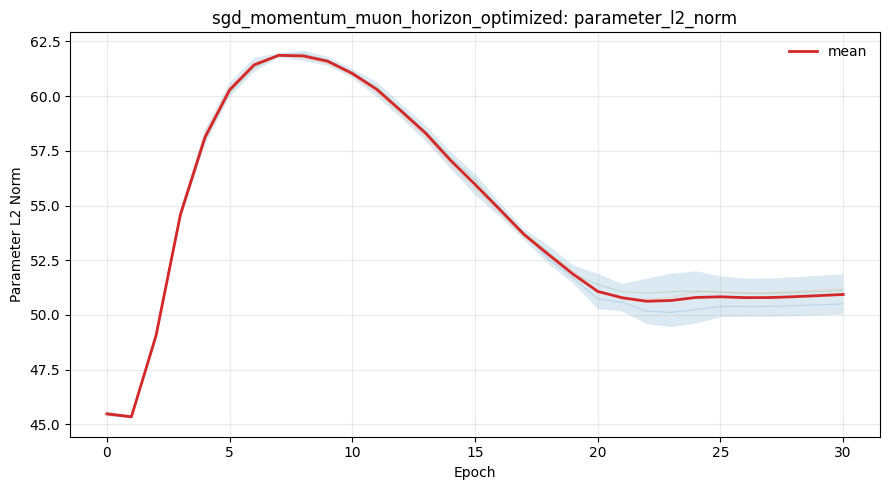

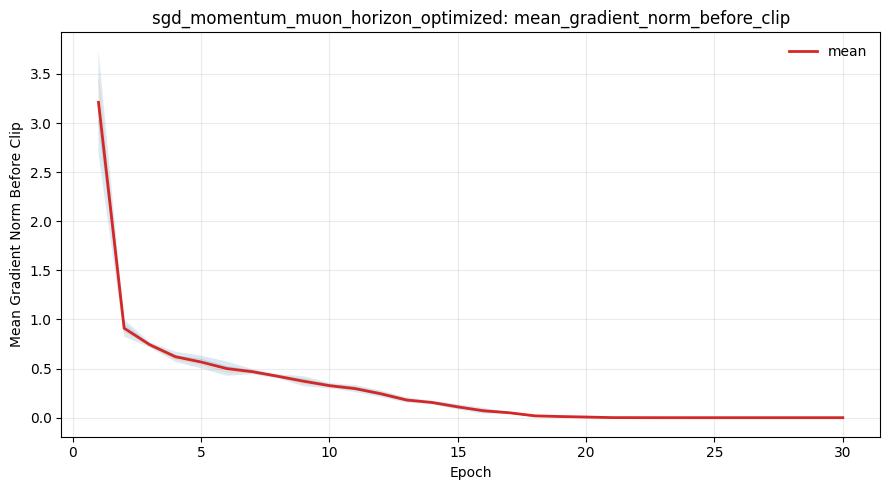

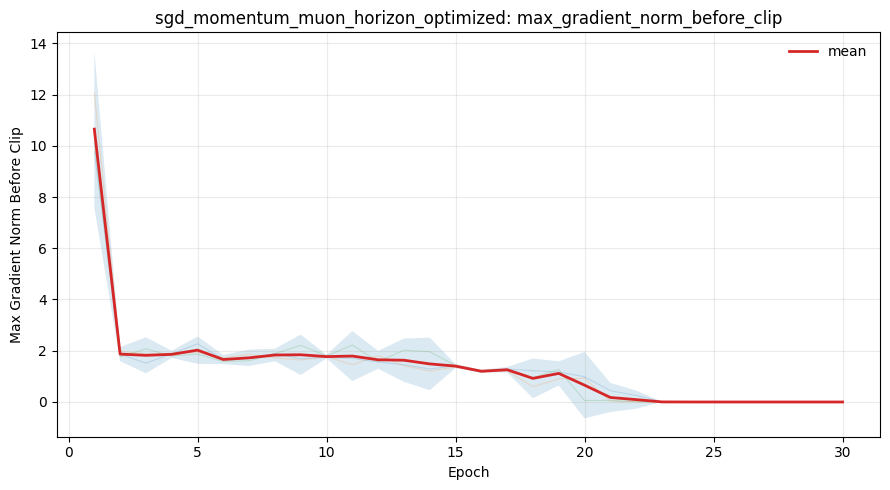

,run,optimizer,optimizer_label,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
7,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,0,auxiliary_lr,3,3.488372e-07,6.483745e-23,3.743392e-23,0.95,4.302653,1.610652e-22,3.488372e-07,3.488372e-07,3.488372e-07,3.488372e-07
24,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,1,auxiliary_lr,3,1.500000e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,1.500000e-04,1.500000e-04,1.500000e-04,1.500000e-04
46,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,2,auxiliary_lr,3,3.000000e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,3.000000e-04,3.000000e-04,3.000000e-04,3.000000e-04
68,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,3,auxiliary_lr,3,2.990704e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.990704e-04,2.990704e-04,2.990704e-04,2.990704e-04
90,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,4,auxiliary_lr,3,2.962848e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.962848e-04,2.962848e-04,2.962848e-04,2.962848e-04
112,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,5,auxiliary_lr,3,2.916781e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.916781e-04,2.916781e-04,2.916781e-04,2.916781e-04
134,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,6,auxiliary_lr,3,2.853083e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.853083e-04,2.853083e-04,2.853083e-04,2.853083e-04
156,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,7,auxiliary_lr,3,2.772555e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.772555e-04,2.772555e-04,2.772555e-04,2.772555e-04
178,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,8,auxiliary_lr,3,2.676210e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.676210e-04,2.676210e-04,2.676210e-04,2.676210e-04
200,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,9,auxiliary_lr,3,2.565259e-04,0.000000e+00,0.000000e+00,0.95,4.302653,0.000000e+00,2.565259e-04,2.565259e-04,2.565259e-04,2.565259e-04


In [4]:
metrics = [
    'train_loss', 'validation_loss', 'test_loss',
    'train_accuracy', 'validation_accuracy', 'test_accuracy',
    'validation_loss_gap', 'test_loss_gap',
    'validation_accuracy_gap', 'test_accuracy_gap',
    'primary_lr', 'auxiliary_lr', 'parameter_l2_norm',
    'mean_gradient_norm_before_clip', 'max_gradient_norm_before_clip',
]
for metric in metrics:
    if metric not in suite.performance.columns:
        continue
    summary = suite.performance_summary[suite.performance_summary['metric'].eq(metric)].sort_values('epoch')
    if summary.empty:
        continue
    figure, axis = plt.subplots(figsize=(9, 5))
    for seed, run in suite.performance.groupby('seed'):
        axis.plot(run['epoch'], run[metric], alpha=0.18, linewidth=0.8)
    axis.plot(summary['epoch'], summary['mean'], linewidth=2.0, label='mean')
    axis.fill_between(summary['epoch'], summary['ci_low'], summary['ci_high'], alpha=0.16)
    axis.set(xlabel='Epoch', ylabel=metric.replace('_', ' ').title(), title=f'{RUN_DIR.name}: {metric}')
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
    figure.tight_layout()
    figure.savefig(PLOT_DIR / f'{metric}_95ci.png', dpi=170, bbox_inches='tight')
    plt.show()

display(suite.performance_summary[suite.performance_summary['metric'].isin(metrics)].sort_values(['metric', 'epoch']))


In [5]:
required = [
    'alpha', 'ERG_gap', 'num_traps', 'm_midpoint',
    'trace_log_midpoint_per_eval', 'stable_rank',
    'normalized_lambda_max',
]
rows = suite.spectral_summary[suite.spectral_summary['metric'].isin(required)].sort_values(['metric', 'layer', 'epoch'])
assert rows['n'].eq(3).all()
display(rows)


,run,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
33,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,1,ERG_gap,3,385.666667,7.371115,4.255715,0.95,4.302653,18.310864,367.355802,403.977531,380.000000,394.000000
62,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,2,ERG_gap,3,363.666667,19.502137,11.259564,0.95,4.302653,48.445993,315.220674,412.112660,344.000000,383.000000
91,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,3,ERG_gap,3,313.333333,29.022979,16.756425,0.95,4.302653,72.097078,241.236256,385.430411,280.000000,333.000000
120,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,4,ERG_gap,3,290.000000,14.106736,8.144528,0.95,4.302653,35.043075,254.956925,325.043075,277.000000,305.000000
149,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,5,ERG_gap,3,257.000000,25.709920,14.843629,0.95,4.302653,63.866982,193.133018,320.866982,237.000000,286.000000
178,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,6,ERG_gap,3,234.666667,28.536526,16.475571,0.95,4.302653,70.888661,163.778006,305.555328,207.000000,264.000000
207,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,7,ERG_gap,3,242.000000,21.000000,12.124356,0.95,4.302653,52.166892,189.833108,294.166892,218.000000,257.000000
236,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,8,ERG_gap,3,255.000000,63.174362,36.473735,0.95,4.302653,156.933815,98.066185,411.933815,186.000000,310.000000
265,Muon + auxiliary AdamW,sgd_momentum_muon,Muon + auxiliary AdamW,fc1,9,ERG_gap,3,210.666667,40.698075,23.497045,0.95,4.302653,101.099624,109.567043,311.766290,175.000000,255.000000


In [6]:
required_paths = [
    RUN_DIR / 'performance_by_epoch_and_seed.csv',
    RUN_DIR / 'spectral_metrics_by_epoch_layer_and_seed.csv',
    RUN_DIR / 'performance_summary_95ci.csv',
    RUN_DIR / 'spectral_summary_95ci.csv',
    RUN_DIR / 'replicate_manifest.json',
]
for seed in SEEDS:
    seed_dir = RUN_DIR / 'seeds' / f'seed_{seed}'
    required_paths.extend([
        seed_dir / 'checkpoint_latest.pt',
        seed_dir / 'checkpoint_best.pt',
        seed_dir / 'final_state.pt',
        seed_dir / 'test_results.json',
        seed_dir / 'run_complete.json',
    ])
missing = [path for path in required_paths if not path.is_file()]
if missing:
    raise RuntimeError('Missing required artifacts:' + chr(10) + chr(10).join(map(str, missing)))
print('verified artifacts:', len(required_paths))


verified artifacts: 20
